# Sweep `build_reduced_fov_path` parameter combinations (40X objective)

Copy of `02_sweep_reduced_fov_path_combinations.ipynb` -- the only
intended difference is the objective (`40X` instead of `60X`); see
section 3 below for why the step size can't just be copied over too.

`positions.py`'s `build_reduced_fov_path` unifies the grid-building choice
(regular vs. irregular, optional grid-offset-phase optimization) with
mandatory redundant-FOV removal (`find_fully_redundant_fovs` -- always
applied, not a toggle) into one function call, mirroring
`segment_mosaic_tissue`'s single-function design for boundary derivation.

This notebook sweeps every combination of its two requested parameters --
`irregular_grid` and `optimize_offset` -- against a real mosaic-derived
boundary, to find which combination gives the lowest FOV count. The
irregular-grid combinations also sweep `fixed_axis` ("y"/"x") on top of
that: it's a real, non-trivial parameter of `build_irregular_boundary_path`/
`optimize_irregular_grid` not mentioned in the original request, so 4
combinations becomes 6 (2 regular + 2x2 irregular).

**Verify step (before implementing)**: is there another function, similar
to `optimize_grid_offset`, that has been investigated but not implemented
for reducing FOV count? Reviewed `FINDINGS.md` and every
`notebooks/tests/decrease_fov_number/*.ipynb` -- no. The only two
grid-phase-search functions that exist (`optimize_grid_offset` for the
regular grid, `optimize_irregular_grid` for the irregular one) are both
already implemented, and `find_fully_redundant_fovs` (the other lever) is
too. The only *other* lever this investigation surfaced (boundary
tightening -- tighter `segment_mosaic_tissue` morphology parameters) is not
a grid-building function and already shipped as `02_create_boundary_from_
mosaic.ipynb`'s production defaults -- out of scope here.


## 1 — Setup


In [1]:
import os
import sys
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.ops import unary_union

# notebooks/tests/<subfolder>/ is three levels under the repo root (MERci/),
# same convention as before_imaging/{regular,multi_z}/ -- see CLAUDE.md.
MERCI_DIR  = Path(os.getcwd()).parent.parent.parent   # MERci/
SAMPLE_DIR = MERCI_DIR.parent
sys.path.insert(0, str(MERCI_DIR / "src"))

from MERci.acquisition.configs   import get_fov_geometry
from MERci.acquisition.positions import (
    load_boundary_polygon, load_hole_polygons, build_reduced_fov_path,
)
from MERci.visualization import get_merci_figures_dir

NOTEBOOK_NAME = "04_sweep_reduced_fov_path_combinations_40x"
DATA_DIR      = MERCI_DIR / "cache" / "tests" / "create_positions" / NOTEBOOK_NAME / "data" / "boundary"
FIGURES_DIR   = get_merci_figures_dir(SAMPLE_DIR, "tests", NOTEBOOK_NAME, subfolder="create_positions")

print(f"MERCI_DIR  : {MERCI_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")


MERCI_DIR  : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci
DATA_DIR   : /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/tests/create_positions/04_sweep_reduced_fov_path_combinations_40x/data/boundary
FIGURES_DIR: /n/home06/lsepulvedaduran/251225_LT027_saving_time/figures/MERci/tests/create_positions/04_sweep_reduced_fov_path_combinations_40x


## 2 — Load the benchmark boundary (real LT066_sample_01/merfish mosaic-derived tissue)

Same real "lineage_merfish" acquisition used throughout
`notebooks/tests/decrease_fov_number/` -- a real, complex single-tissue
boundary + 11 holes, produced by that experiment's own
`02_create_boundary_from_mosaic.ipynb` run (production defaults). Copied
once into this notebook's own `DATA_DIR` (see `NOTEBOOK_GUIDELINES.md`'s
"Test notebooks: stay portable" section) so every later cell reads only
from there, never the live experiment tree.


In [2]:
# One-time copy from the real experiment tree -- skipped once DATA_DIR exists.
SOURCE_BOUNDARY_DIR = Path(
    "/n/holylfs05/LABS/zhuang_lab/Lab/shared/projects/lineage_tracing/experiments/"
    "LT066_sample_01/merfish/positions/boundaries/from_mosaic"
)
if not DATA_DIR.exists():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for f in sorted(SOURCE_BOUNDARY_DIR.glob("*.txt")):
        shutil.copy2(f, DATA_DIR / f.name)
    print(f"Copied {len(list(DATA_DIR.glob('*.txt')))} boundary/hole file(s) "
          f"from LT066_sample_01/merfish (production from_mosaic boundary).")
else:
    print(f"Using existing local copy: {DATA_DIR}")

boundary_polygon = load_boundary_polygon(DATA_DIR / "boundary_positions.txt")
hole_polygons    = load_hole_polygons(DATA_DIR)
effective_tissue = boundary_polygon.difference(unary_union(hole_polygons)) if hole_polygons else boundary_polygon

print(f"Boundary area: {boundary_polygon.area / 1e6:.2f} mm^2")
print(f"Tissue area (boundary minus holes): {effective_tissue.area / 1e6:.2f} mm^2")
print(f"Holes      : {len(hole_polygons)}")


Using existing local copy: /n/home06/lsepulvedaduran/251225_LT027_saving_time/MERci/cache/tests/create_positions/04_sweep_reduced_fov_path_combinations_40x/data/boundary
Boundary area: 34.82 mm^2
Tissue area (boundary minus holes): 30.60 mm^2
Holes      : 11


## 3 — FOV/grid geometry (40X objective)

Same ST2 microscope as notebook 02, but the `40X` objective
(`get_fov_geometry("ST2", "40X")` -- a scaled-from-60X placeholder, see
`acquisition/configs.py`'s own comment: no real 40X calibration exists
yet). Notebook 02's `STEP_SIZE_UM` was a value measured directly from this
experiment's own real 60X production FOVs -- there's no equivalent real
40X measurement (this dataset was never imaged at 40X), so here
`STEP_SIZE_UM` is the standard `non_overlap_fraction * FOV_SIZE_UM`
formula (`0.9`, the same convention `before_imaging/02_create_positions_
from_boundaries.ipynb` and `notebooks/tests/40x_objective/01_compare_60x_
40x_objective_fov_coverage.ipynb` already use for a derived objective).


In [3]:
NON_OVERLAP_FRACTION = 0.9   # same convention as before_imaging/02 and 40x_objective/01

pixel_size_um, image_size_px = get_fov_geometry("ST2", "40X")
FOV_SIZE_UM  = pixel_size_um * image_size_px
STEP_SIZE_UM = FOV_SIZE_UM * NON_OVERLAP_FRACTION

print(f"Pixel size: {pixel_size_um:.4f} um/px")
print(f"FOV size  : {FOV_SIZE_UM:.2f} um")
print(f"Step size : {STEP_SIZE_UM:.2f} um")


Pixel size: 0.1317 um/px
FOV size  : 303.44 um
Step size : 273.09 um


## 4 — Sweep every combination

`irregular_grid` x `optimize_offset` x (`fixed_axis` for the irregular
combinations only) -- 6 combinations total. Each calls
`build_reduced_fov_path` once; redundant-FOV removal is always applied
(not swept -- see this notebook's own intro cell).


In [4]:
COMBOS = [
    dict(label="regular",                          irregular_grid=False, optimize_offset=False, fixed_axis=None),
    dict(label="regular + optimize_offset",         irregular_grid=False, optimize_offset=True,  fixed_axis=None),
    dict(label="irregular (fixed_axis=y)",          irregular_grid=True,  optimize_offset=False, fixed_axis="y"),
    dict(label="irregular (fixed_axis=y) + offset", irregular_grid=True,  optimize_offset=True,  fixed_axis="y"),
    dict(label="irregular (fixed_axis=x)",          irregular_grid=True,  optimize_offset=False, fixed_axis="x"),
    dict(label="irregular (fixed_axis=x) + offset", irregular_grid=True,  optimize_offset=True,  fixed_axis="x"),
]

results = {}
for i, combo in enumerate(COMBOS):
    kwargs = dict(step_size=STEP_SIZE_UM, fov_size_um=FOV_SIZE_UM,
                  irregular_grid=combo["irregular_grid"], optimize_offset=combo["optimize_offset"])
    if combo["fixed_axis"] is not None:
        kwargs["fixed_axis"] = combo["fixed_axis"]
    t0  = time.time()
    res = build_reduced_fov_path(boundary_polygon, hole_polygons, **kwargs)
    dt  = time.time() - t0
    results[combo["label"]] = res
    print(f"[{i+1}/{len(COMBOS)}] {combo['label']:32s} "
          f"n_fovs: {res.n_fovs_before_redundant:4d} -> {len(res.coords):4d}   "
          f"uncovered: {res.redundant.uncovered_area_um2:9.2f} um^2   ({dt:.1f}s)")


[1/6] regular                          n_fovs:  537 ->  515   uncovered:      0.78 um^2   (0.3s)


[2/6] regular + optimize_offset        n_fovs:  530 ->  516   uncovered:    175.85 um^2   (9.6s)


[3/6] irregular (fixed_axis=y)         n_fovs:  537 ->  524   uncovered:      0.00 um^2   (0.3s)


[4/6] irregular (fixed_axis=y) + offset n_fovs:  535 ->  522   uncovered:      0.00 um^2   (1.1s)


[5/6] irregular (fixed_axis=x)         n_fovs:  541 ->  517   uncovered:      0.00 um^2   (0.3s)


[6/6] irregular (fixed_axis=x) + offset n_fovs:  532 ->  524   uncovered:      0.00 um^2   (0.9s)


## 5 — Summary table

`coverage_safe` flags combinations whose uncovered tissue area, after
redundant-FOV removal, stays below one thousandth of a FOV's own area
(`FOV_SIZE_UM ** 2 / 1000`) -- generous enough to absorb the same kind of
floating-point-residual polygon slivers `find_fully_redundant_fovs`'s own
`eps_um2` check already treats as noise, but far below a real gap. Only
`coverage_safe` combinations lose zero real tissue coverage relative to the
starting grid and are directly comparable on FOV count alone.


In [5]:
COVERAGE_EPS_UM2 = FOV_SIZE_UM ** 2 / 1000

rows = []
for label, res in results.items():
    uncovered = res.redundant.uncovered_area_um2
    rows.append(dict(
        combination=label,
        n_fovs_before_redundant=res.n_fovs_before_redundant,
        n_fovs_final=len(res.coords),
        n_redundant_removed=len(res.redundant.removed),
        uncovered_area_um2=uncovered,
        coverage_safe=uncovered < COVERAGE_EPS_UM2,
    ))
summary_df = pd.DataFrame(rows)
summary_df


,combination,n_fovs_before_redundant,n_fovs_final,n_redundant_removed,uncovered_area_um2,coverage_safe
0,regular,537,515,22,0.781776,True
1,regular + optimize_offset,530,516,14,175.847279,False
2,irregular (fixed_axis=y),537,524,13,0.000000,True
3,irregular (fixed_axis=y) + offset,535,522,13,0.000000,True
4,irregular (fixed_axis=x),541,517,24,0.000000,True
5,irregular (fixed_axis=x) + offset,532,524,8,0.000000,True


In [6]:
safe_df = summary_df[summary_df["coverage_safe"]]
if len(safe_df) == 0:
    print("WARNING: no combination is coverage-safe -- every one loses real tissue coverage.")
else:
    winner = safe_df.loc[safe_df["n_fovs_final"].idxmin()]
    print(f"Lowest FOV count among coverage-safe combinations: "
          f"'{winner['combination']}' -> {winner['n_fovs_final']} FOVs "
          f"(uncovered {winner['uncovered_area_um2']:.4f} um^2)")

unsafe_df = summary_df[~summary_df["coverage_safe"]]
if len(unsafe_df) > 0:
    print(f"\n{len(unsafe_df)}/{len(summary_df)} combination(s) are NOT coverage-safe "
          f"(real tissue left uncovered) -- excluded from the FOV-count comparison above:")
    for _, r in unsafe_df.iterrows():
        print(f"  {r['combination']:32s} uncovered {r['uncovered_area_um2']:9.2f} um^2 "
              f"({r['n_fovs_final']} FOVs)")


Lowest FOV count among coverage-safe combinations: 'regular' -> 515 FOVs (uncovered 0.7818 um^2)

1/6 combination(s) are NOT coverage-safe (real tissue left uncovered) -- excluded from the FOV-count comparison above:
  regular + optimize_offset        uncovered    175.85 um^2 (516 FOVs)


## 6 — Overlay plot: boundary + FOVs, every combination


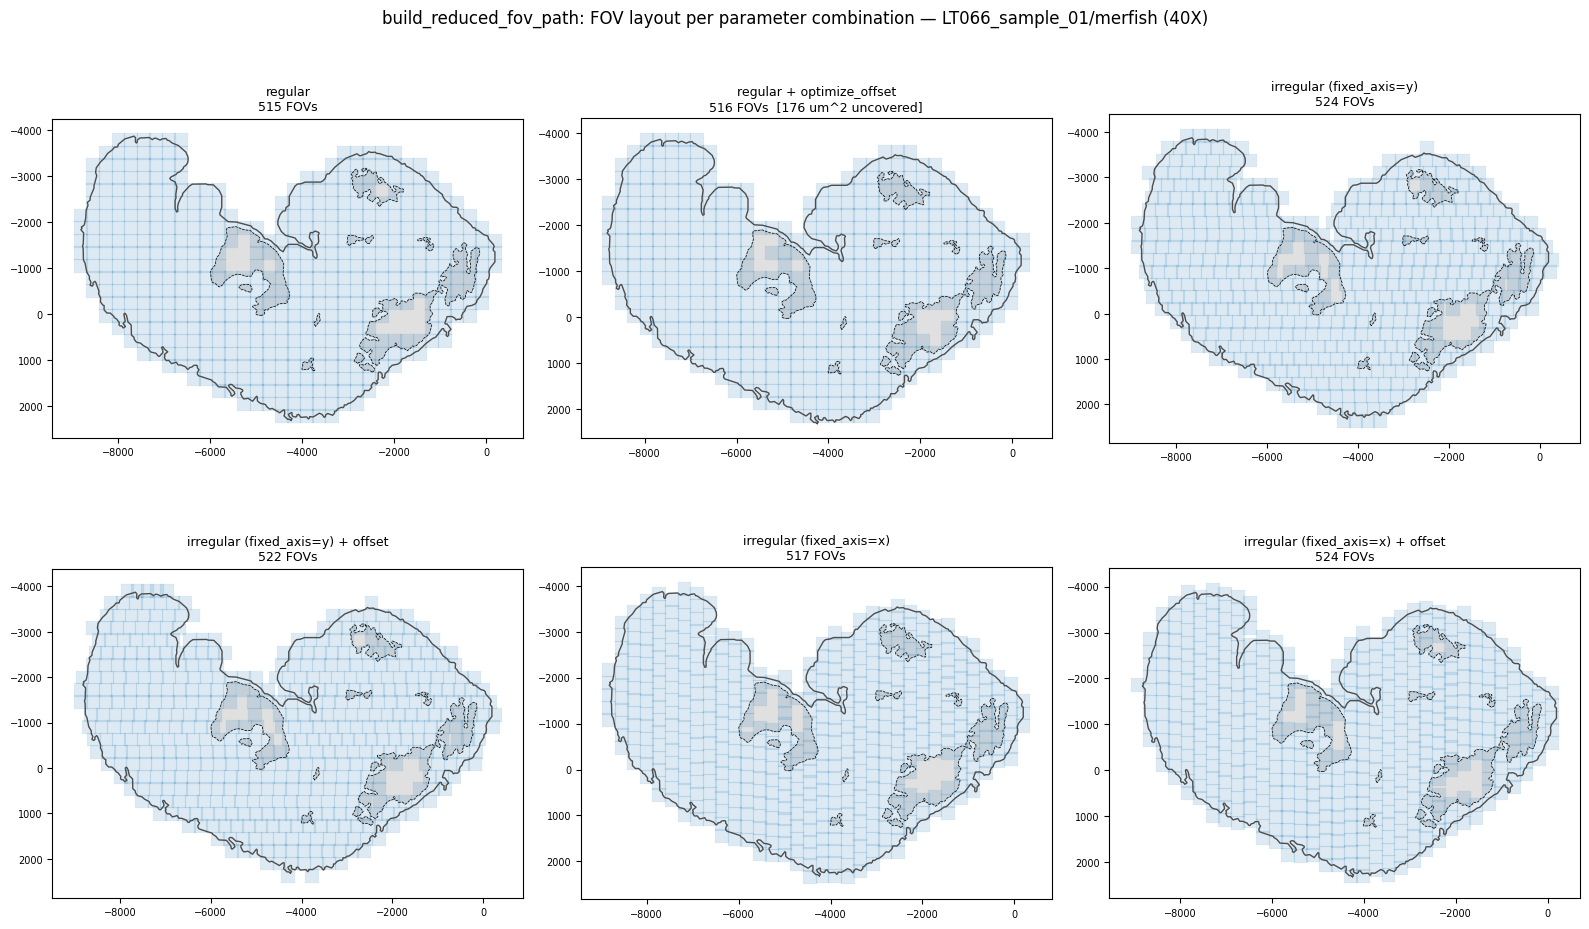

In [7]:
half = FOV_SIZE_UM / 2

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, (label, res) in zip(axes.flat, results.items()):
    ax.plot(*boundary_polygon.exterior.xy, "-", lw=1.0, color="0.3")
    for hole in hole_polygons:
        ax.fill(*hole.exterior.xy, color="0.8", alpha=0.6)
        ax.plot(*hole.exterior.xy, "k--", lw=0.5)
    for x, y in res.coords:
        ax.add_patch(mpatches.Rectangle(
            (x - half, y - half), FOV_SIZE_UM, FOV_SIZE_UM,
            lw=0.2, edgecolor="tab:blue", facecolor="tab:blue", alpha=0.15,
        ))
    uncovered = res.redundant.uncovered_area_um2
    flag = "" if uncovered < COVERAGE_EPS_UM2 else f"  [{uncovered:.0f} um^2 uncovered]"
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"{label}\n{len(res.coords)} FOVs{flag}", fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("build_reduced_fov_path: FOV layout per parameter combination — LT066_sample_01/merfish (40X)", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_layout_overlay.png", dpi=150)
plt.show()


## 7 — Bar graph: FOV count per combination


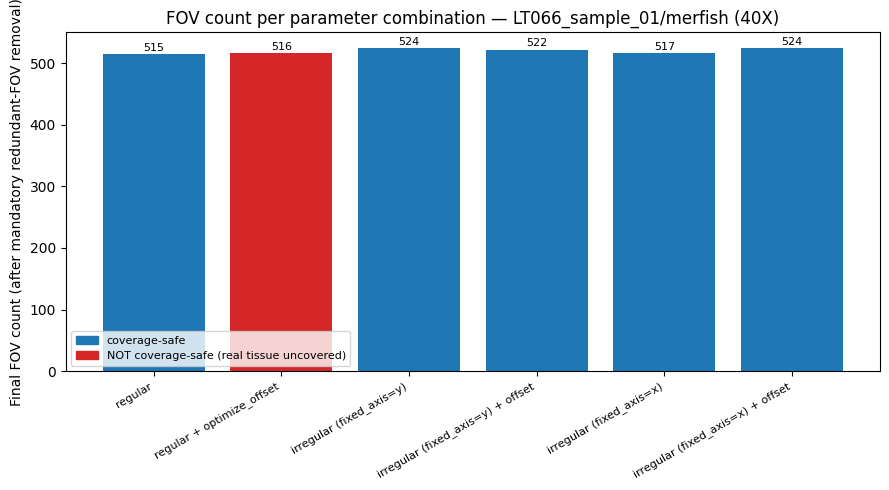

In [8]:
labels = list(results.keys())
n_fovs = [len(results[l].coords) for l in labels]
colors = ["tab:blue" if summary_df.set_index("combination").loc[l, "coverage_safe"]
          else "tab:red" for l in labels]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(range(len(labels)), n_fovs, color=colors)
for bar, n in zip(bars, n_fovs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, str(n),
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Final FOV count (after mandatory redundant-FOV removal)")
ax.set_title("FOV count per parameter combination — LT066_sample_01/merfish (40X)")
ax.legend(handles=[
    mpatches.Patch(color="tab:blue", label="coverage-safe"),
    mpatches.Patch(color="tab:red",  label="NOT coverage-safe (real tissue uncovered)"),
], fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / f"{NOTEBOOK_NAME}.fov_count_bar.png", dpi=150)
plt.show()


## 8 — Takeaways

- **40X vs. 60X (same real boundary, same tissue)**: FOV size 303.44 um
  (vs. 202.29 um at 60X, matching the 1.5x = 60/40 magnification ratio,
  ~2.25x the area), step size 273.09 um (derived, `0.9 * FOV_SIZE_UM` --
  no real 40X measurement exists for this dataset). Far fewer FOVs needed
  overall (515-524 vs. 1096-1113 at 60X) -- consistent with
  `40x_objective/01_compare_60x_40x_objective_fov_coverage.ipynb`'s
  earlier finding that a lower-magnification objective needs roughly
  `(60/40)^2 = 2.25x` fewer FOVs to cover the same tissue.

- **Winner**: plain `regular` (no offset optimization) -> **515 FOVs**,
  coverage-safe (0.78 um^2 uncovered, noise-floor) -- same overall
  pattern as the 60X sweep.

- **New finding, not previously seen at 60X: `regular + optimize_offset`
  is NOT coverage-safe at 40X** (175.85 um^2 real tissue uncovered, a
  single gap right at the boundary's own bbox edge). Root-caused: this
  boundary's `y`-bbox span sits at `22.65 * STEP_SIZE_UM` (very little
  slack past a whole multiple of the step size), and the winning searched
  offset (`dy = -75.86` um, close to the `+-136.5` um search range's
  edge) shifts the grid's centre enough that the outermost row's own FOV
  footprint no longer quite reaches the boundary's true `ymax` edge --
  `create_grid_positions`'s offset mechanism (`cx`/`cy` shifted, but the
  point COUNT is still sized only from the *unshifted* bbox span) has no
  guard against this. This is a real, previously-undocumented gap in
  `build_boundary_path_optimized`/`optimize_grid_offset` themselves --
  `patch_uncovered_gaps` is NOT wired there (only into
  `build_irregular_boundary_path`), so nothing currently closes it. Not
  fixed in this notebook (out of scope -- flagged for a follow-up, same
  as the irregular-grid gap was in `03_guarantee_irregular_grid_
  coverage.ipynb` before it was fixed).
